In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, LSTM, GRU,
                                     SimpleRNN, Bidirectional, Input,
                                     Concatenate)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

2026-03-04 02:12:01.739479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772590321.920477      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772590321.972727      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772590322.399956      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772590322.399998      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772590322.400001      24 computation_placer.cc:177] computation placer alr

In [2]:
DATA_DIR  = '/kaggle/input/datasets/annn51/mobilenetv2-datasets/processed_data'
MODEL_DIR = '/kaggle/working/models'
PLOTS_DIR = '/kaggle/working/plots'

for d in [MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)


# SECTION 1 — Load saved data from Notebook 1


In [ ]:
print("Loading data...")
X_tr_seq = np.load(os.path.join(DATA_DIR, 'X_tr_seq.npy'))
X_te_seq = np.load(os.path.join(DATA_DIR, 'X_te_seq.npy'))
X_va_seq = np.load(os.path.join(DATA_DIR, 'X_va_seq.npy'))

X_tr_img = np.load(os.path.join(DATA_DIR, 'X_tr_img.npy'))
X_te_img = np.load(os.path.join(DATA_DIR, 'X_te_img.npy'))
X_va_img = np.load(os.path.join(DATA_DIR, 'X_va_img.npy'))

y_tr_seq = np.load(os.path.join(DATA_DIR, 'y_tr_seq.npy')) # 1D labels for sequences
y_te_seq = np.load(os.path.join(DATA_DIR, 'y_te_seq.npy'))
y_va_seq = np.load(os.path.join(DATA_DIR, 'y_va_seq.npy'))

print(f"Sequences — Train: {X_tr_seq.shape} | Test: {X_te_seq.shape}")
print(f"Images    — Train: {X_tr_img.shape} | Test: {X_te_img.shape}")
print(f"Class distribution — Train: {np.bincount(y_tr_seq)}")

WINDOW   = X_tr_seq.shape[1]   # 600
IMG_SIZE = X_tr_img.shape[1]   # 224

Loading data...
Sequences — Train: (4246, 600, 2) | Test: (913, 600, 2)
Images    — Train: (4246, 224, 224, 3) | Test: (913, 224, 224, 3)
Class distribution — Train: [3564  231  451]


# SECTION 2 — EDA on loaded data


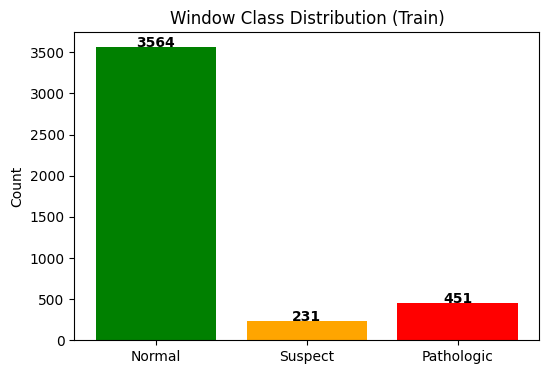

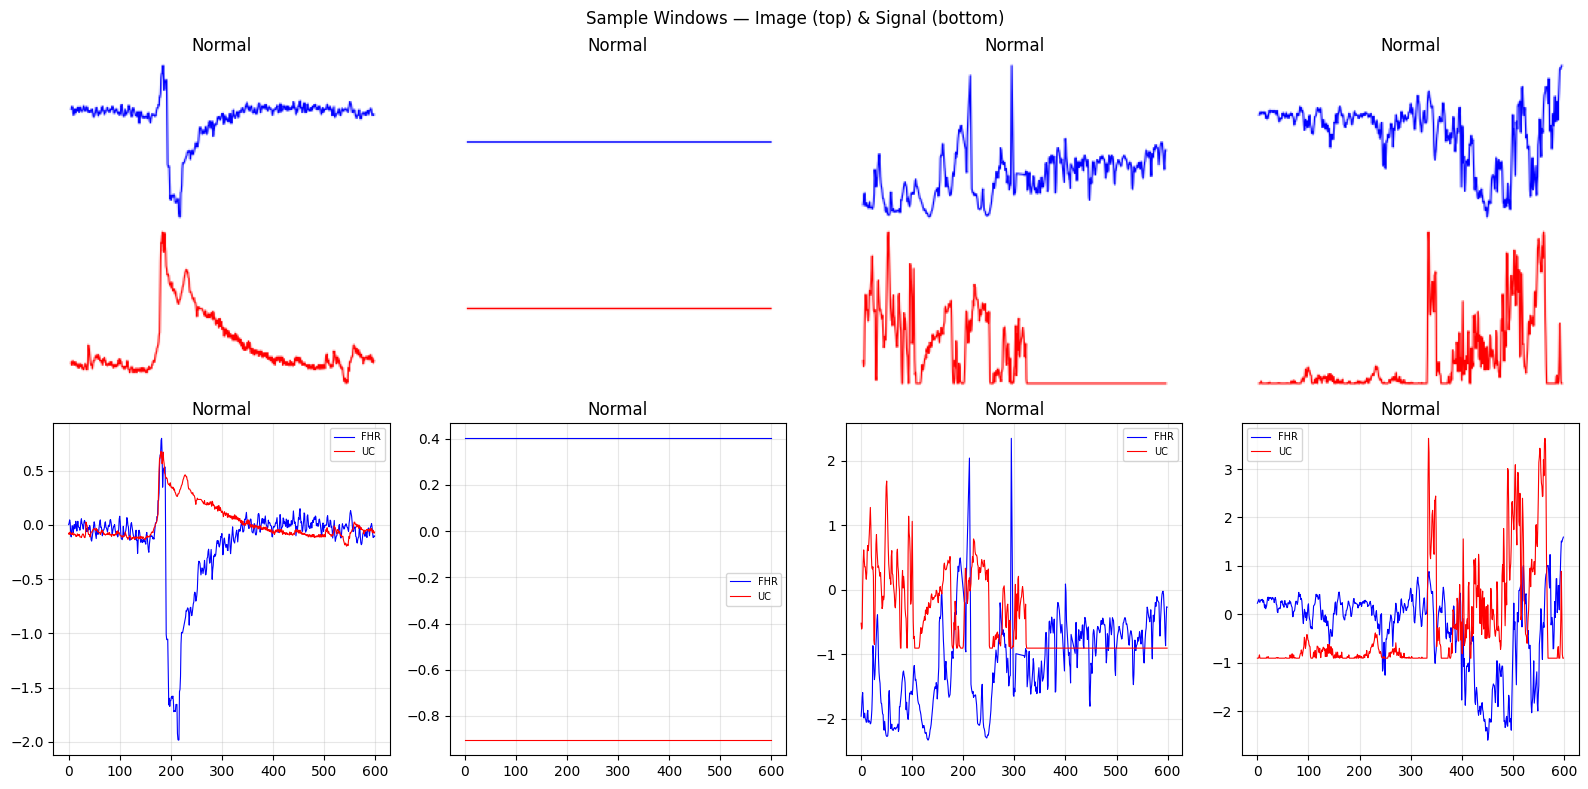

In [4]:
# Class distribution
plt.figure(figsize=(6, 4))
label_names = ['Normal', 'Suspect', 'Pathologic']
counts      = np.bincount(y_tr_seq)
plt.bar(label_names, counts, color=['green', 'orange', 'red'])
plt.title('Window Class Distribution (Train)')
plt.ylabel('Count')
for i, c in enumerate(counts):
    plt.text(i, c+1, str(c), ha='center', fontweight='bold')
plt.savefig(os.path.join(PLOTS_DIR, 'class_dist_nb2.png'))
plt.show()

# Sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes[0]):
    idx = i * 10
    ax.imshow(X_tr_img[idx])
    ax.set_title(f'{label_names[y_tr_seq[idx]]}')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    idx = i * 10
    ax.plot(X_tr_seq[idx, :, 0], color='blue',  linewidth=0.8, label='FHR')
    ax.plot(X_tr_seq[idx, :, 1], color='red',   linewidth=0.8, label='UC')
    ax.set_title(f'{label_names[y_tr_seq[idx]]}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('Sample Windows — Image (top) & Signal (bottom)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sample_windows_nb2.png'))
plt.show()

# SECTION 3 — Setup


In [5]:
cw_arr      = compute_class_weight('balanced', classes=np.unique(y_tr_seq), y=y_tr_seq)
class_weights = dict(enumerate(cw_arr))
print(f"Class weights: {class_weights}")

y_tr_cat = to_categorical(y_tr_seq, 3)
y_te_cat = to_categorical(y_te_seq, 3)
y_va_cat = to_categorical(y_va_seq, 3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
]


Class weights: {0: np.float64(0.39711934156378603), 1: np.float64(6.126984126984127), 2: np.float64(3.138211382113821)}


# SECTION 4 — MobileNetV2 HYBRID MODEL



MobileNetV2+LSTM_1L_64u


I0000 00:00:1772590361.152960      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  Phase 1: frozen MobileNetV2...


I0000 00:00:1772590378.107767      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Phase 2: fine-tuning...
  Test Acc: 0.7579 | Best Val Acc: 0.8138
              precision    recall  f1-score   support

      Normal       0.86      0.87      0.87       770
     Suspect       0.04      0.02      0.03        44
  Pathologic       0.18      0.20      0.19        99

    accuracy                           0.76       913
   macro avg       0.36      0.37      0.36       913
weighted avg       0.75      0.76      0.75       913



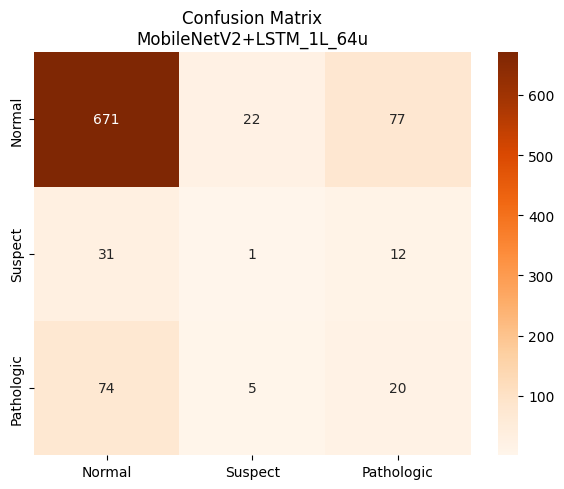

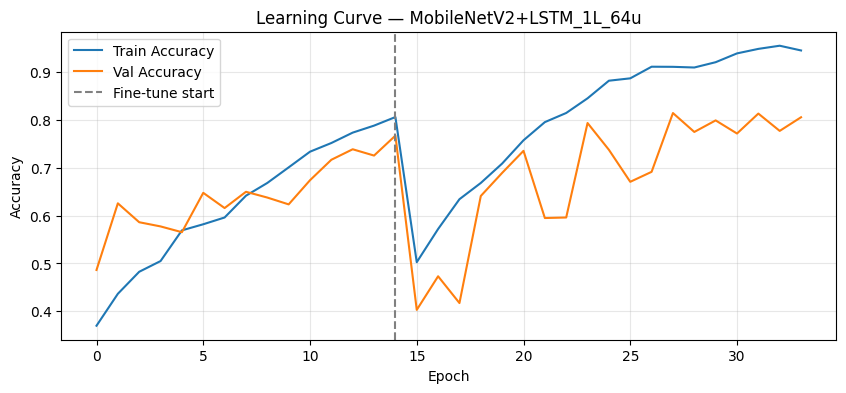

  ✓ Saved

MobileNetV2+LSTM_2L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7306 | Best Val Acc: 0.8083
              precision    recall  f1-score   support

      Normal       0.87      0.82      0.85       770
     Suspect       0.09      0.11      0.10        44
  Pathologic       0.22      0.28      0.24        99

    accuracy                           0.73       913
   macro avg       0.39      0.41      0.40       913
weighted avg       0.77      0.73      0.75       913



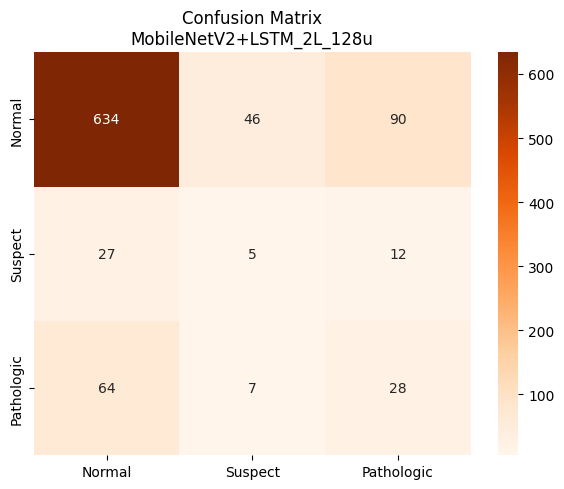

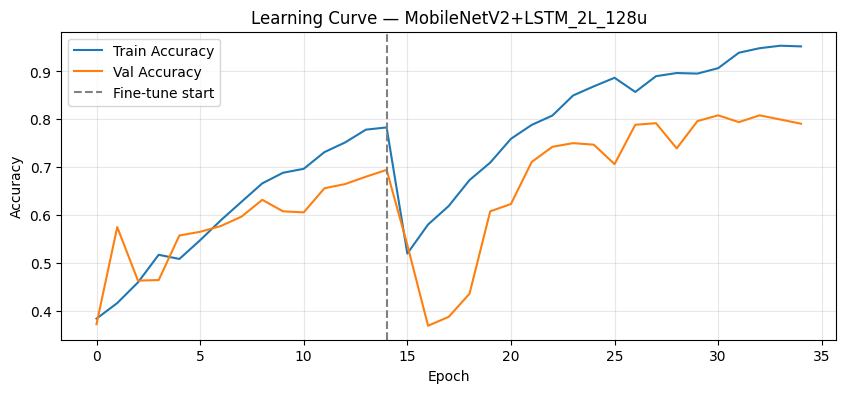

  ✓ Saved

MobileNetV2+LSTM_3L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7612 | Best Val Acc: 0.8324
              precision    recall  f1-score   support

      Normal       0.87      0.87      0.87       770
     Suspect       0.15      0.11      0.13        44
  Pathologic       0.19      0.21      0.20        99

    accuracy                           0.76       913
   macro avg       0.40      0.40      0.40       913
weighted avg       0.76      0.76      0.76       913



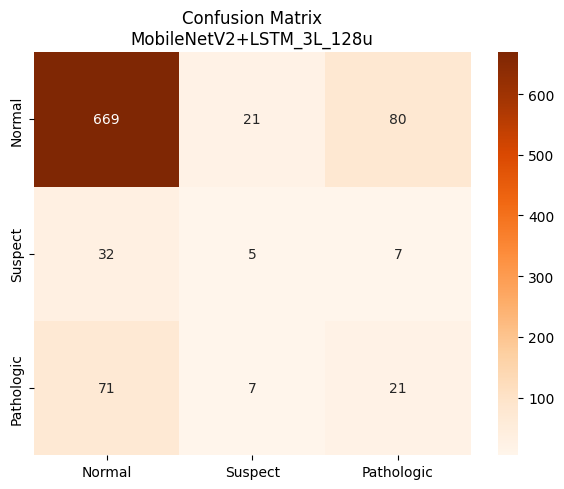

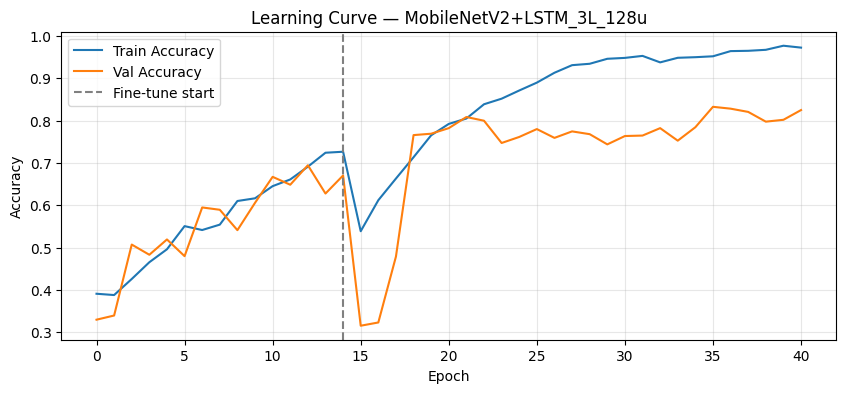

  ✓ Saved

MobileNetV2+LSTM_2L_256u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7087 | Best Val Acc: 0.7809
              precision    recall  f1-score   support

      Normal       0.87      0.81      0.84       770
     Suspect       0.08      0.11      0.09        44
  Pathologic       0.16      0.21      0.18        99

    accuracy                           0.71       913
   macro avg       0.37      0.38      0.37       913
weighted avg       0.75      0.71      0.73       913



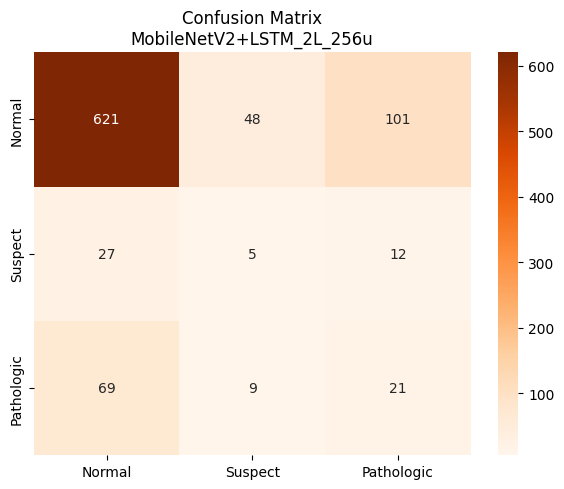

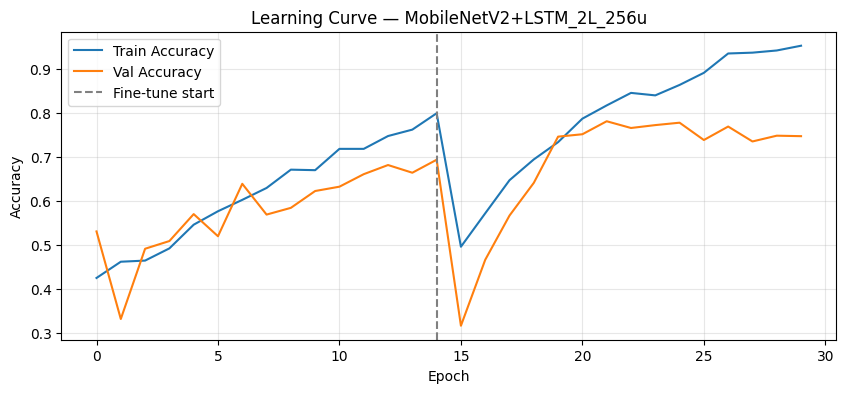

  ✓ Saved

MobileNetV2+BiLSTM_2L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7470 | Best Val Acc: 0.8269
              precision    recall  f1-score   support

      Normal       0.88      0.84      0.86       770
     Suspect       0.15      0.16      0.16        44
  Pathologic       0.21      0.27      0.24        99

    accuracy                           0.75       913
   macro avg       0.41      0.42      0.42       913
weighted avg       0.77      0.75      0.76       913



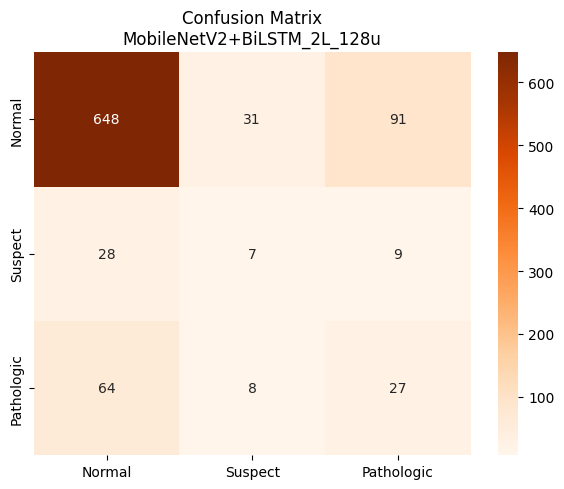

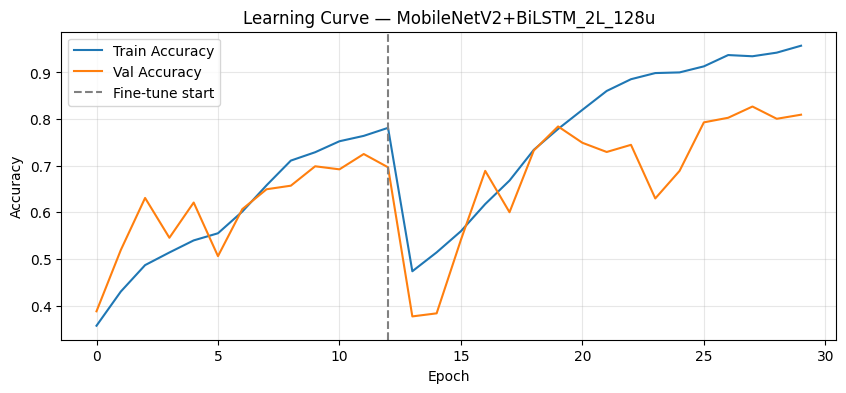

  ✓ Saved

MobileNetV2+BiLSTM_3L_256u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7349 | Best Val Acc: 0.8368
              precision    recall  f1-score   support

      Normal       0.87      0.84      0.85       770
     Suspect       0.10      0.07      0.08        44
  Pathologic       0.17      0.25      0.20        99

    accuracy                           0.73       913
   macro avg       0.38      0.39      0.38       913
weighted avg       0.76      0.73      0.75       913



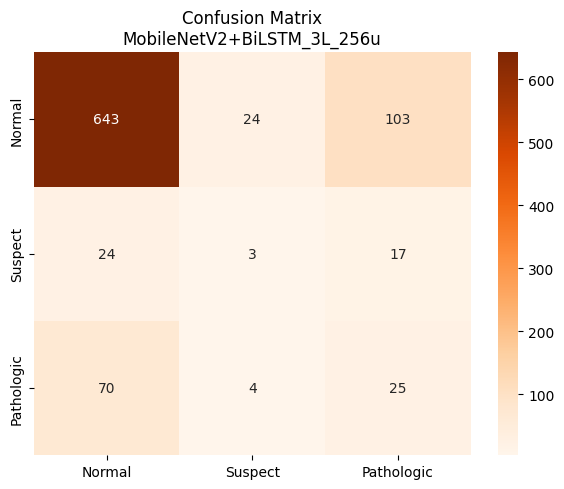

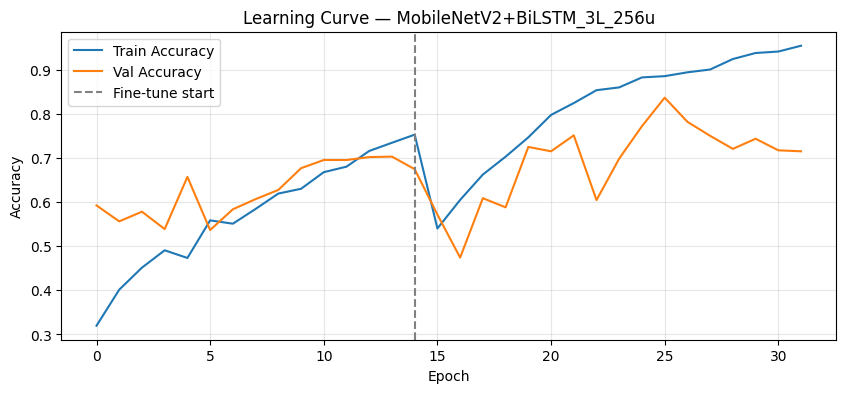

  ✓ Saved

MobileNetV2+GRU_1L_64u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7470 | Best Val Acc: 0.8116
              precision    recall  f1-score   support

      Normal       0.86      0.86      0.86       770
     Suspect       0.09      0.09      0.09        44
  Pathologic       0.14      0.14      0.14        99

    accuracy                           0.75       913
   macro avg       0.36      0.36      0.36       913
weighted avg       0.75      0.75      0.75       913



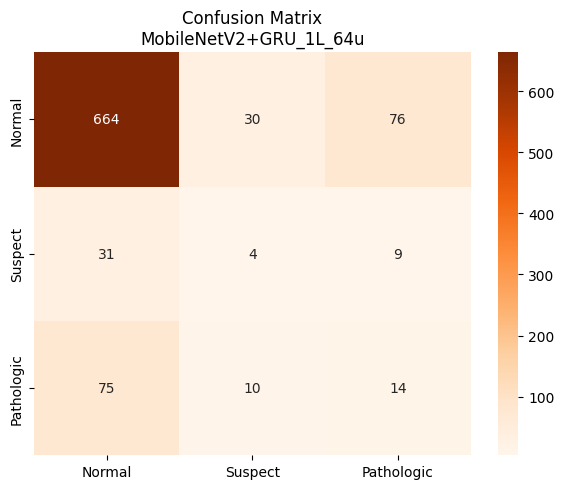

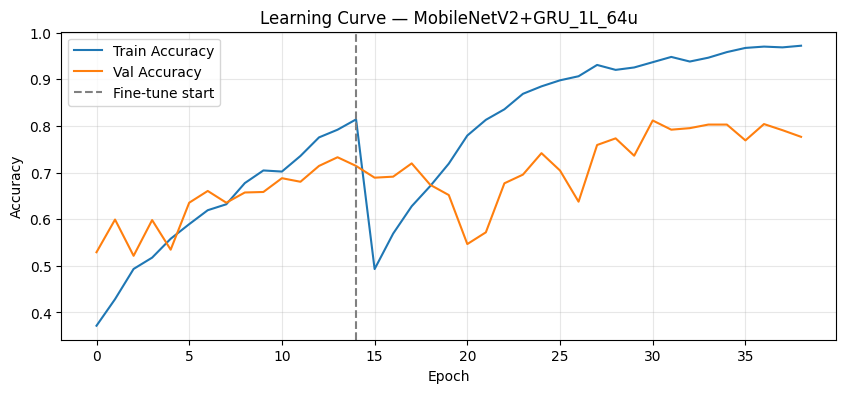

  ✓ Saved

MobileNetV2+GRU_2L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7744 | Best Val Acc: 0.8324
              precision    recall  f1-score   support

      Normal       0.85      0.89      0.87       770
     Suspect       0.00      0.00      0.00        44
  Pathologic       0.23      0.19      0.21        99

    accuracy                           0.77       913
   macro avg       0.36      0.36      0.36       913
weighted avg       0.74      0.77      0.76       913



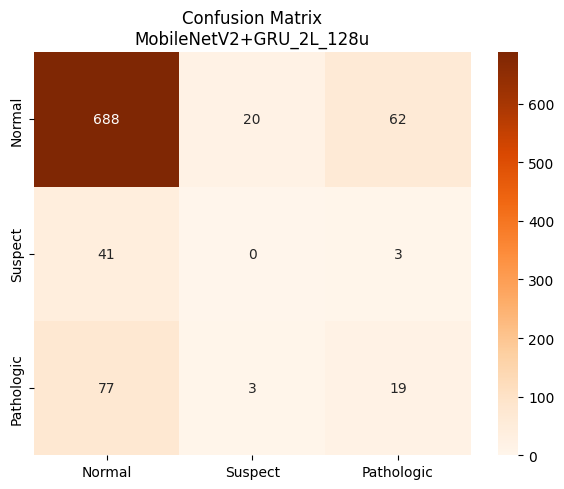

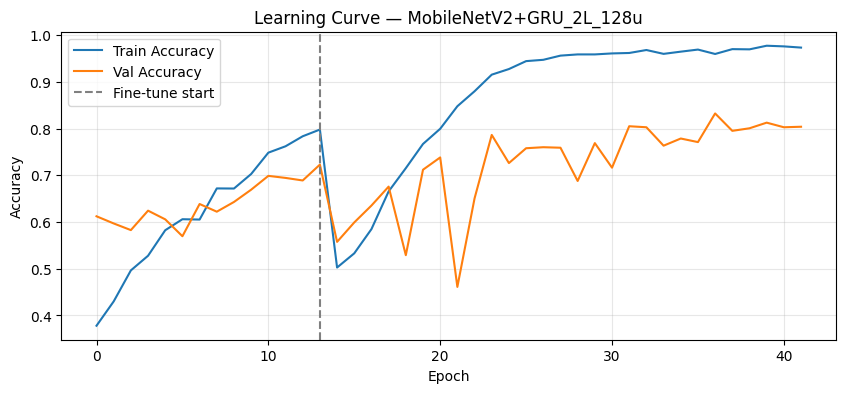

  ✓ Saved

MobileNetV2+GRU_3L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7788 | Best Val Acc: 0.8050
              precision    recall  f1-score   support

      Normal       0.86      0.90      0.88       770
     Suspect       0.12      0.16      0.14        44
  Pathologic       0.22      0.11      0.15        99

    accuracy                           0.78       913
   macro avg       0.40      0.39      0.39       913
weighted avg       0.75      0.78      0.76       913



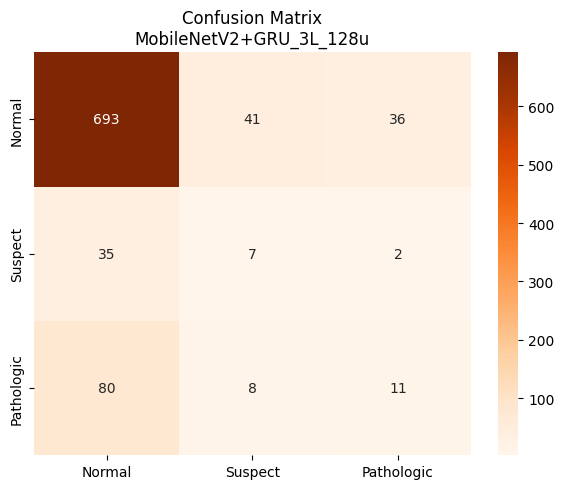

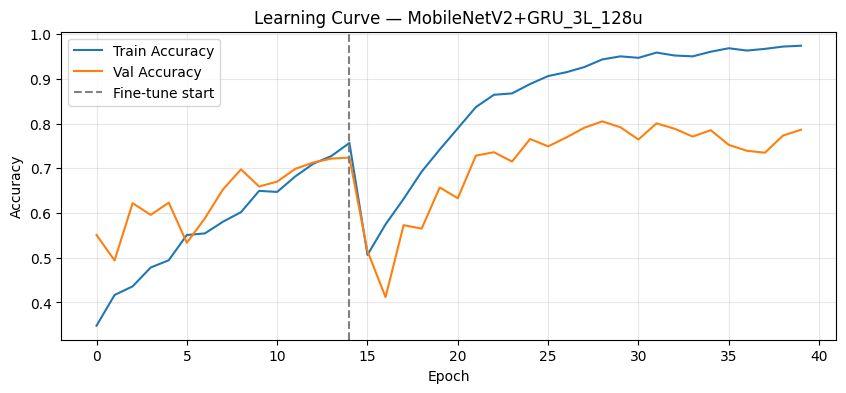

  ✓ Saved

MobileNetV2+GRU_2L_256u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7284 | Best Val Acc: 0.7623
              precision    recall  f1-score   support

      Normal       0.88      0.82      0.85       770
     Suspect       0.12      0.16      0.14        44
  Pathologic       0.20      0.28      0.24        99

    accuracy                           0.73       913
   macro avg       0.40      0.42      0.41       913
weighted avg       0.77      0.73      0.75       913



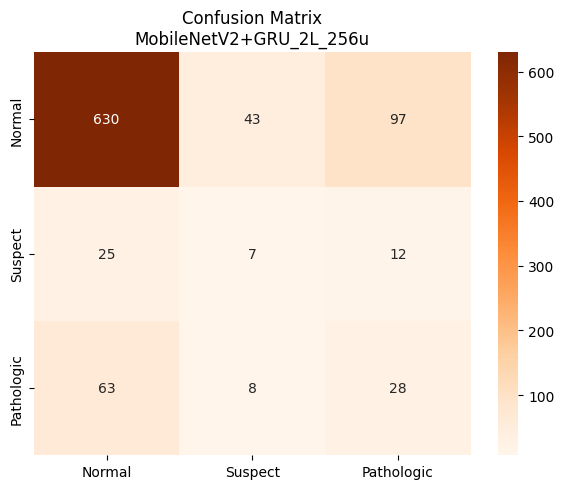

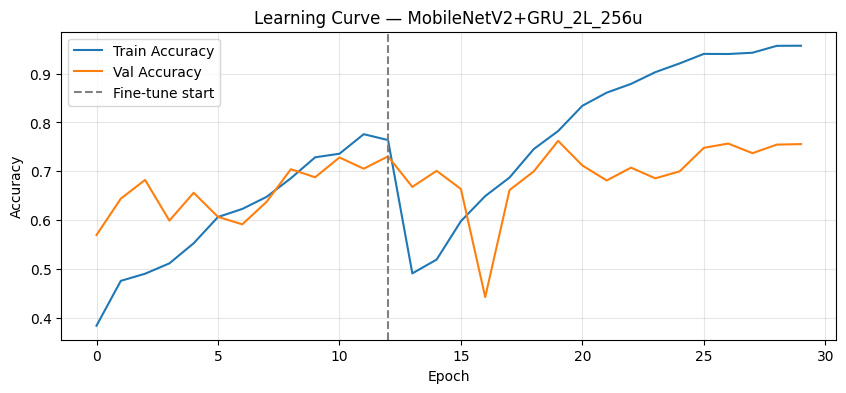

  ✓ Saved

MobileNetV2+BiGRU_2L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7974 | Best Val Acc: 0.8050
              precision    recall  f1-score   support

      Normal       0.86      0.92      0.89       770
     Suspect       0.06      0.05      0.05        44
  Pathologic       0.25      0.14      0.18        99

    accuracy                           0.80       913
   macro avg       0.39      0.37      0.38       913
weighted avg       0.76      0.80      0.77       913



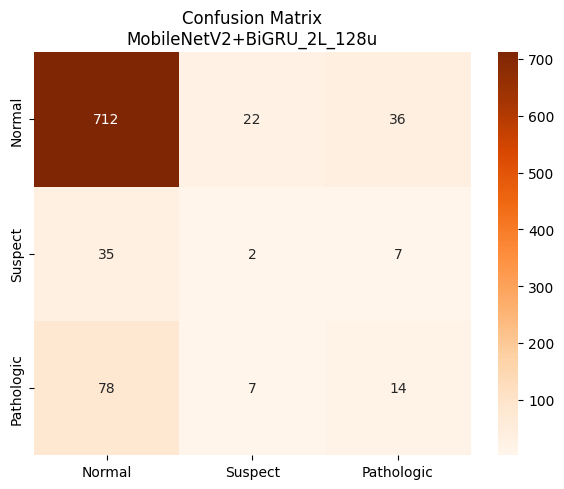

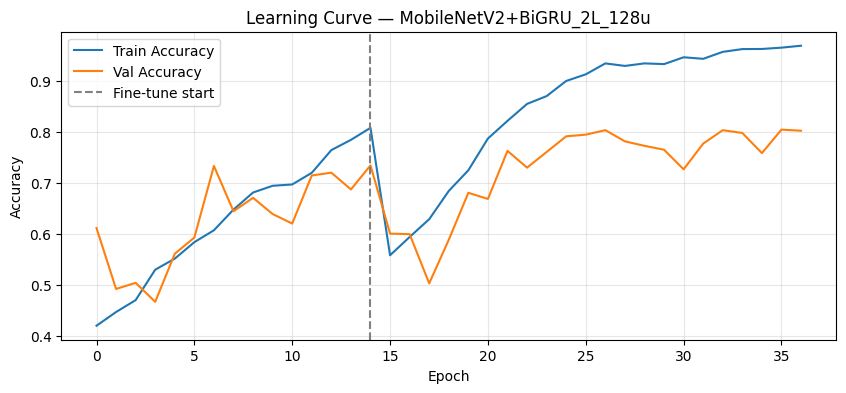

  ✓ Saved

MobileNetV2+BiGRU_3L_256u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7525 | Best Val Acc: 0.8028
              precision    recall  f1-score   support

      Normal       0.87      0.87      0.87       770
     Suspect       0.03      0.05      0.04        44
  Pathologic       0.20      0.18      0.19        99

    accuracy                           0.75       913
   macro avg       0.37      0.36      0.37       913
weighted avg       0.76      0.75      0.76       913



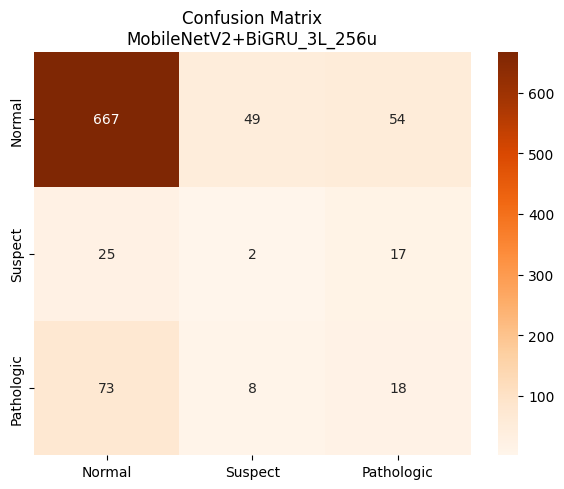

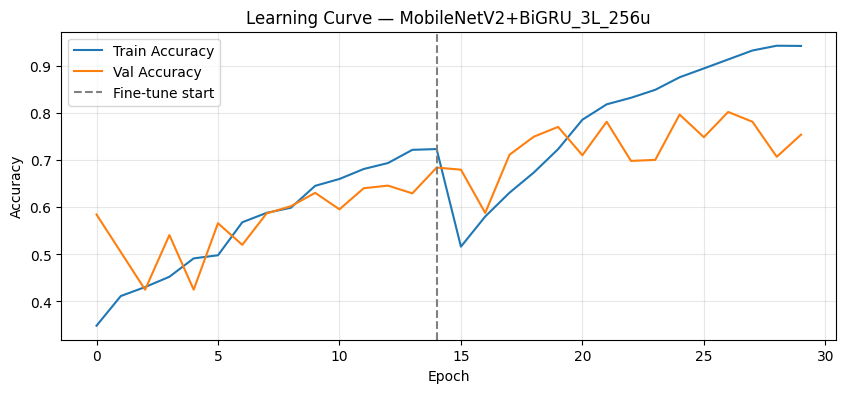

  ✓ Saved

MobileNetV2+RNN_1L_64u
  Phase 1: frozen MobileNetV2...


I0000 00:00:1772601777.545430      67 service.cc:152] XLA service 0x7d7f65ba5950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772601777.545509      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772601787.016554      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Phase 2: fine-tuning...


2026-03-04 05:26:01.649008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 05:26:01.845180: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 05:26:02.044668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Test Acc: 0.7514 | Best Val Acc: 0.7963
              precision    recall  f1-score   support

      Normal       0.86      0.87      0.87       770
     Suspect       0.03      0.05      0.04        44
  Pathologic       0.21      0.14      0.17        99

    accuracy                           0.75       913
   macro avg       0.37      0.35      0.36       913
weighted avg       0.75      0.75      0.75       913



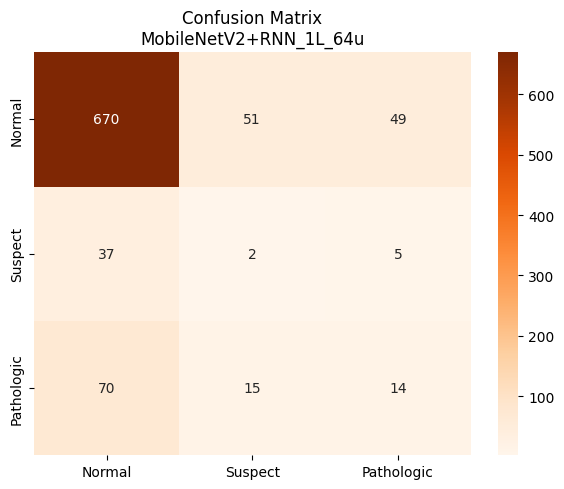

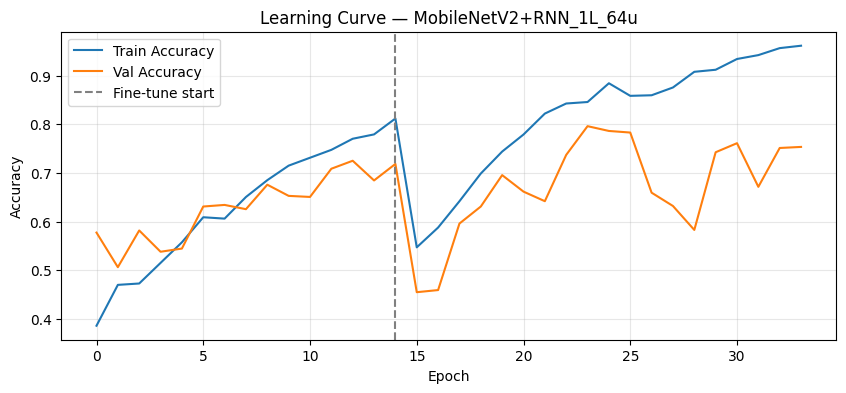

  ✓ Saved

MobileNetV2+RNN_2L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.7656 | Best Val Acc: 0.8094
              precision    recall  f1-score   support

      Normal       0.87      0.88      0.87       770
     Suspect       0.03      0.05      0.04        44
  Pathologic       0.31      0.20      0.24        99

    accuracy                           0.77       913
   macro avg       0.40      0.38      0.38       913
weighted avg       0.76      0.77      0.76       913



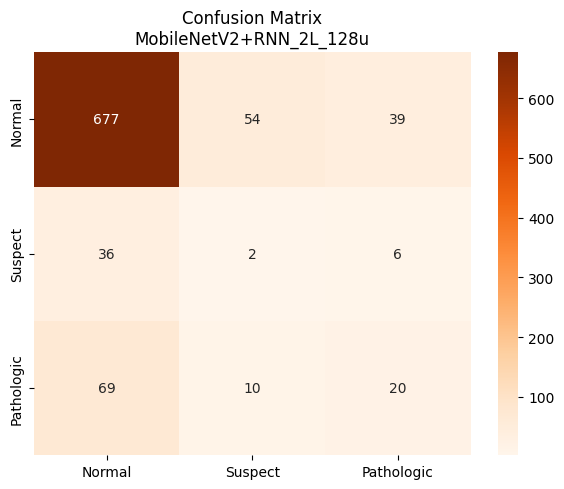

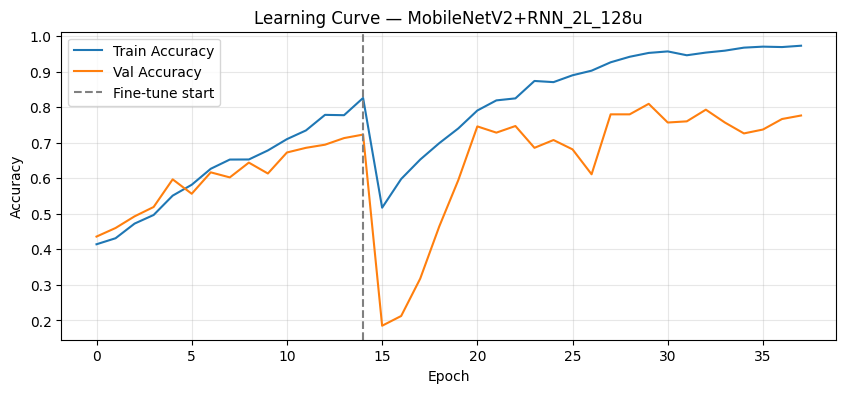

  ✓ Saved

MobileNetV2+BiRNN_2L_128u
  Phase 1: frozen MobileNetV2...
  Phase 2: fine-tuning...
  Test Acc: 0.6900 | Best Val Acc: 0.7568
              precision    recall  f1-score   support

      Normal       0.86      0.78      0.82       770
     Suspect       0.09      0.18      0.12        44
  Pathologic       0.16      0.20      0.18        99

    accuracy                           0.69       913
   macro avg       0.37      0.39      0.37       913
weighted avg       0.75      0.69      0.72       913



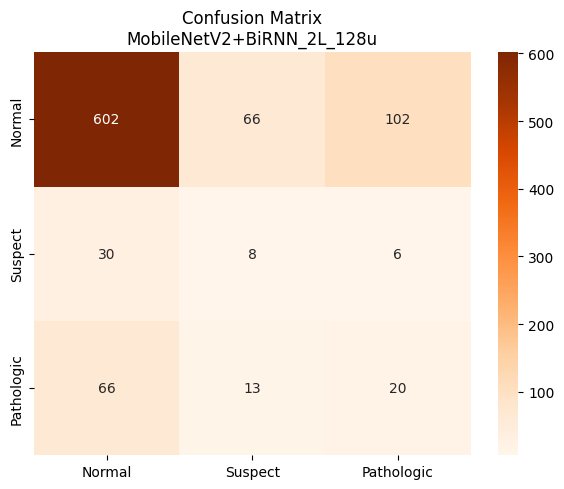

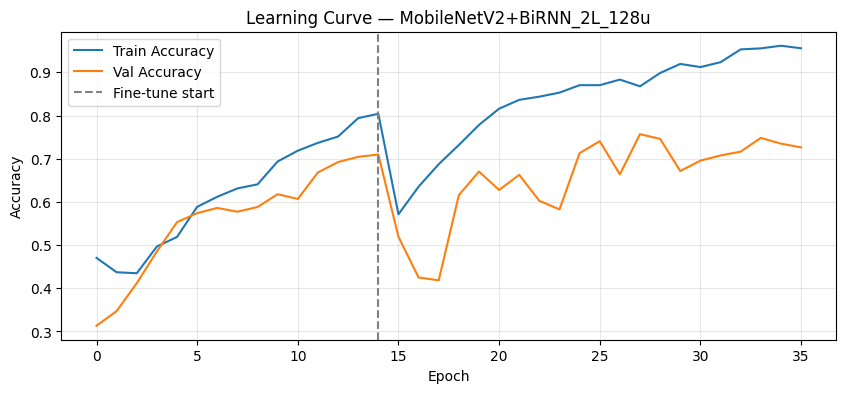

  ✓ Saved


In [6]:
def build_mobilenet_hybrid(rnn_arch, rnn_units, rnn_layers,
                           bidirectional=False, dropout=0.3):
    # CNN branch
    img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_input')
    base      = MobileNetV2(weights='imagenet', include_top=False,
                            input_tensor=img_input)
    base.trainable = False

    cnn_x = GlobalAveragePooling2D()(base.output)
    cnn_x = BatchNormalization()(cnn_x)
    cnn_x = Dense(128, activation='relu')(cnn_x)
    cnn_x = Dropout(dropout)(cnn_x)

    # RNN branch
    seq_input = Input(shape=(WINDOW, 2), name='seq_input')
    layer_fn  = {'LSTM': LSTM, 'GRU': GRU, 'RNN': SimpleRNN}[rnn_arch]

    x = seq_input
    for i in range(rnn_layers):
        ret_seq = (i < rnn_layers - 1)
        layer   = layer_fn(rnn_units, return_sequences=ret_seq)
        x       = Bidirectional(layer)(x) if bidirectional else layer(x)
        x       = BatchNormalization()(x)
        x       = Dropout(dropout)(x)

    rnn_x = Dense(64, activation='relu')(x)
    rnn_x = Dropout(dropout)(rnn_x)

    # Merge
    merged = Concatenate()([cnn_x, rnn_x])
    merged = Dense(128, activation='relu')(merged)
    merged = BatchNormalization()(merged)
    merged = Dropout(0.3)(merged)
    merged = Dense(64,  activation='relu')(merged)
    output = Dense(3, activation='softmax')(merged)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
    return model, base

# Same experiment configs as Notebook 1 for fair comparison
mobilenet_configs = [
    ('LSTM',   64,    1,  False, 0.3),
    ('LSTM',   128,   2,  False, 0.3),
    ('LSTM',   128,   3,  False, 0.4),
    ('LSTM',   256,   2,  False, 0.3),
    ('LSTM',   128,   2,  True,  0.3),
    ('LSTM',   256,   3,  True,  0.4),
    ('GRU',    64,    1,  False, 0.3),
    ('GRU',    128,   2,  False, 0.3),
    ('GRU',    128,   3,  False, 0.4),
    ('GRU',    256,   2,  False, 0.3),
    ('GRU',    128,   2,  True,  0.3),
    ('GRU',    256,   3,  True,  0.4),
    ('RNN',    64,    1,  False, 0.3),
    ('RNN',    128,   2,  False, 0.3),
    ('RNN',    128,   2,  True,  0.3),
]

mobilenet_results   = {}
mobilenet_histories = {}

for rnn, units, layers, bidir, dropout in mobilenet_configs:
    name = f"MobileNetV2+{'Bi' if bidir else ''}{rnn}_{layers}L_{units}u"
    print(f"\n{'='*55}\n{name}")

    model, base = build_mobilenet_hybrid(rnn, units, layers, bidir, dropout)

    # Phase 1 — frozen MobileNetV2
    print("  Phase 1: frozen MobileNetV2...")
    h1 = model.fit(
        [X_tr_img, X_tr_seq], y_tr_cat,
        validation_data=([X_va_img, X_va_seq], y_va_cat),
        epochs=15, batch_size=32,
        class_weight=class_weights,
        callbacks=callbacks, verbose=0
    )

    # Phase 2 — unfreeze top 30 layers
    print("  Phase 2: fine-tuning...")
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    model.compile(Adam(1e-4), 'categorical_crossentropy', metrics=['accuracy'])

    h2 = model.fit(
        [X_tr_img, X_tr_seq], y_tr_cat,
        validation_data=([X_va_img, X_va_seq], y_va_cat),
        epochs=30, batch_size=16,
        class_weight=class_weights,
        callbacks=callbacks, verbose=0
    )

    loss, acc = model.evaluate([X_te_img, X_te_seq], y_te_cat, verbose=0)
    y_pred    = np.argmax(model.predict([X_te_img, X_te_seq], verbose=0), axis=1)
    val_acc   = max(h2.history['val_accuracy'])

    print(f"  Test Acc: {acc:.4f} | Best Val Acc: {val_acc:.4f}")
    print(classification_report(y_te_seq, y_pred,
          target_names=['Normal', 'Suspect', 'Pathologic']))

    # Confusion matrix
    cm = confusion_matrix(y_te_seq, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Normal','Suspect','Pathologic'],
                yticklabels=['Normal','Suspect','Pathologic'])
    plt.title(f'Confusion Matrix\n{name}')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'cm_{name}.png'))
    plt.show()

    # Learning curve
    all_val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    all_trn_acc = h1.history['accuracy']     + h2.history['accuracy']
    plt.figure(figsize=(10, 4))
    plt.plot(all_trn_acc, label='Train Accuracy')
    plt.plot(all_val_acc, label='Val Accuracy')
    plt.axvline(len(h1.history['accuracy'])-1, color='gray',
                linestyle='--', label='Fine-tune start')
    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(PLOTS_DIR, f'lc_{name}.png'))
    plt.show()

    mobilenet_results[name]   = {'test_acc': acc, 'val_acc': val_acc}
    mobilenet_histories[name] = all_val_acc
    model.save(os.path.join(MODEL_DIR, f'{name}.keras'))
    print(f"  ✓ Saved")


# SECTION 5 — RESULTS + FINAL COMPARISON



══ MOBILENETV2 HYBRID RESULTS ══
                            test_acc   val_acc
MobileNetV2+BiGRU_2L_128u   0.797371  0.805038
MobileNetV2+GRU_3L_128u     0.778751  0.805038
MobileNetV2+GRU_2L_128u     0.774370  0.832421
MobileNetV2+RNN_2L_128u     0.765608  0.809420
MobileNetV2+LSTM_3L_128u    0.761227  0.832421
MobileNetV2+LSTM_1L_64u     0.757941  0.813801
MobileNetV2+BiGRU_3L_256u   0.752464  0.802848
MobileNetV2+RNN_1L_64u      0.751369  0.796276
MobileNetV2+BiLSTM_2L_128u  0.746988  0.826944
MobileNetV2+GRU_1L_64u      0.746988  0.811610
MobileNetV2+BiLSTM_3L_256u  0.734940  0.836802
MobileNetV2+LSTM_2L_128u    0.730559  0.808324
MobileNetV2+GRU_2L_256u     0.728368  0.762322
MobileNetV2+LSTM_2L_256u    0.708653  0.780942
MobileNetV2+BiRNN_2L_128u   0.690033  0.756846


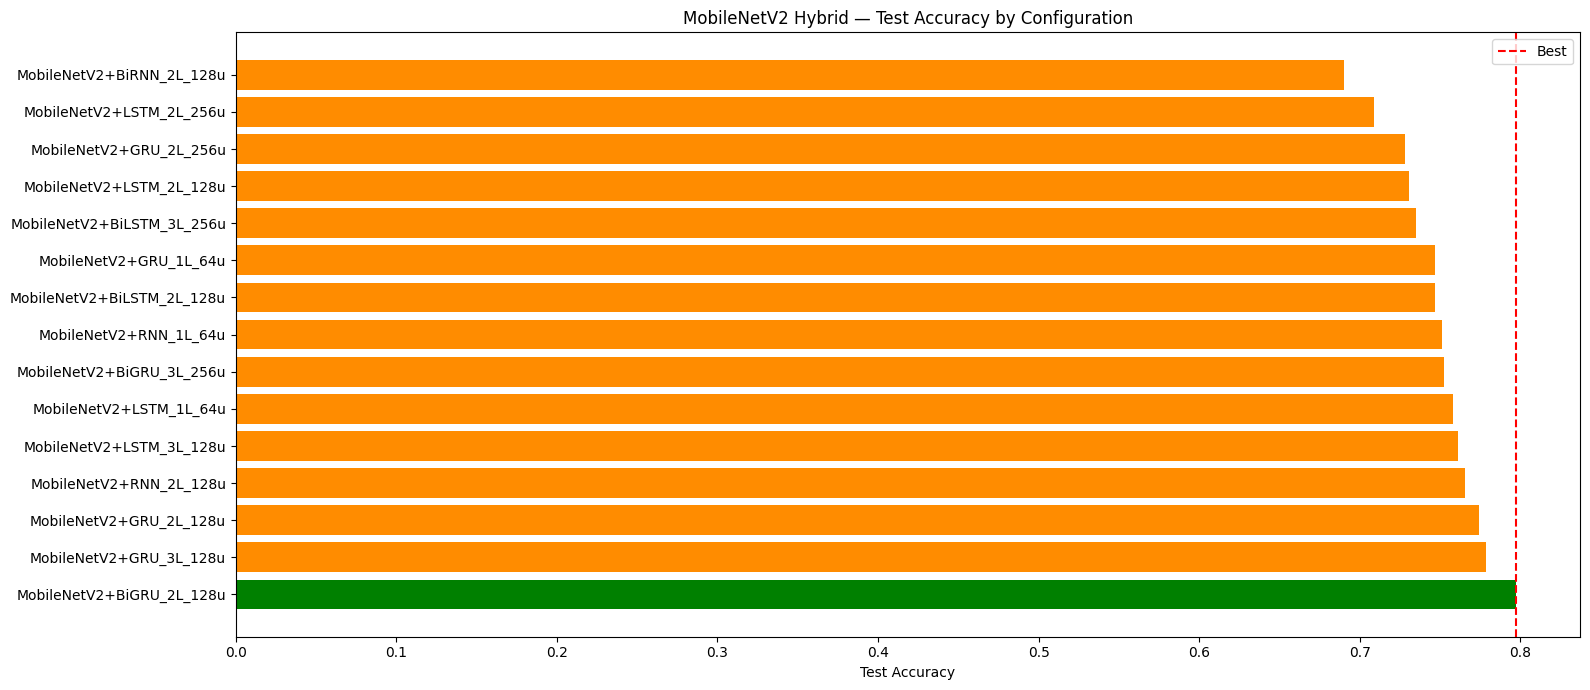

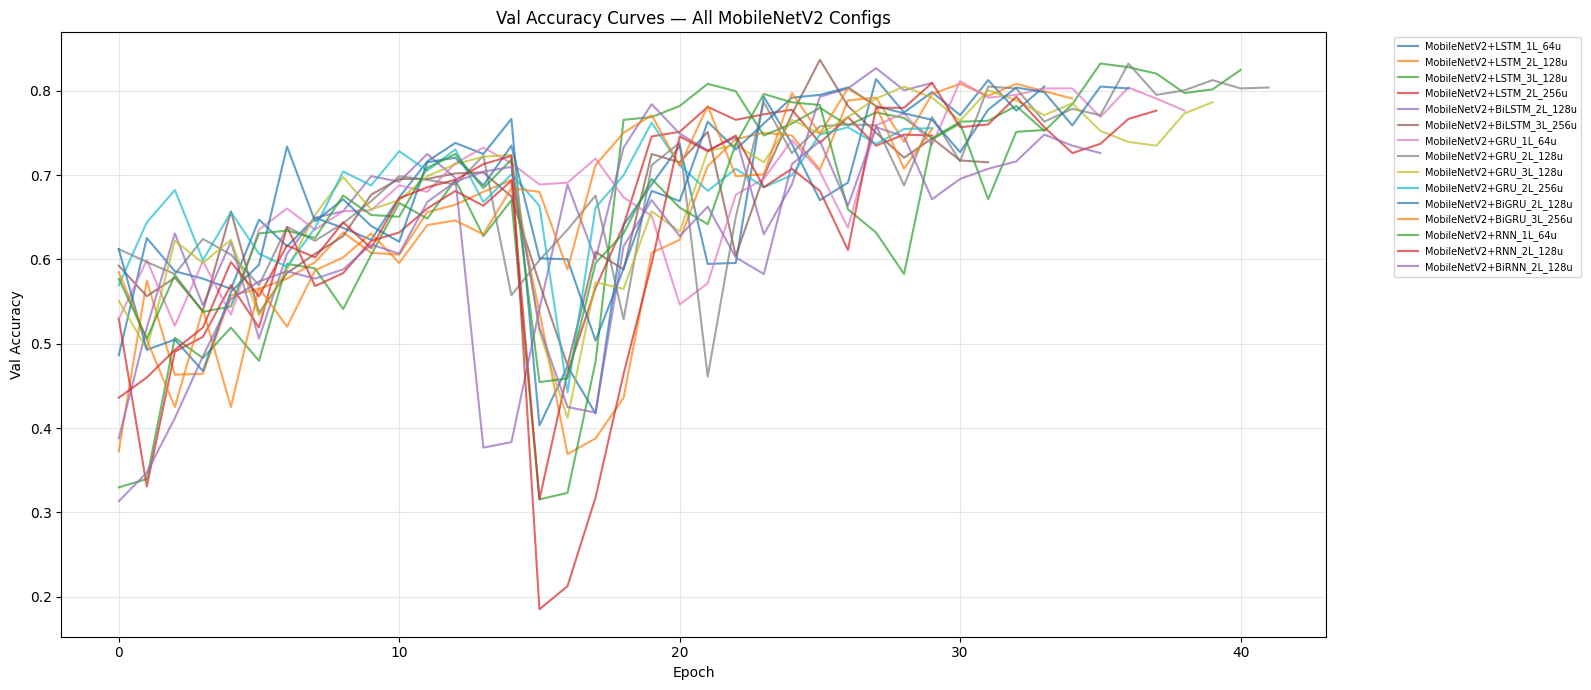

In [7]:
df_mobilenet = pd.DataFrame(mobilenet_results).T.sort_values('test_acc', ascending=False)
print("\n══ MOBILENETV2 HYBRID RESULTS ══")
print(df_mobilenet.to_string())
df_mobilenet.to_csv(os.path.join(MODEL_DIR, 'mobilenetv2_results.csv'))

# MobileNetV2 bar chart
plt.figure(figsize=(16, 7))
colors = ['green' if v == df_mobilenet['test_acc'].max() else 'darkorange'
          for v in df_mobilenet['test_acc']]
plt.barh(df_mobilenet.index, df_mobilenet['test_acc'], color=colors)
plt.axvline(df_mobilenet['test_acc'].max(), color='red',
            linestyle='--', label='Best')
plt.title('MobileNetV2 Hybrid — Test Accuracy by Configuration')
plt.xlabel('Test Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mobilenet_comparison.png'))
plt.show()

# Val curves
plt.figure(figsize=(16, 7))
for name, curve in mobilenet_histories.items():
    plt.plot(curve, label=name, alpha=0.7)
plt.title('Val Accuracy Curves — All MobileNetV2 Configs')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend(fontsize=7, bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mobilenet_all_curves.png'))
plt.show()


# Cross-notebook comparison 
# Load ResNet results from Notebook 1

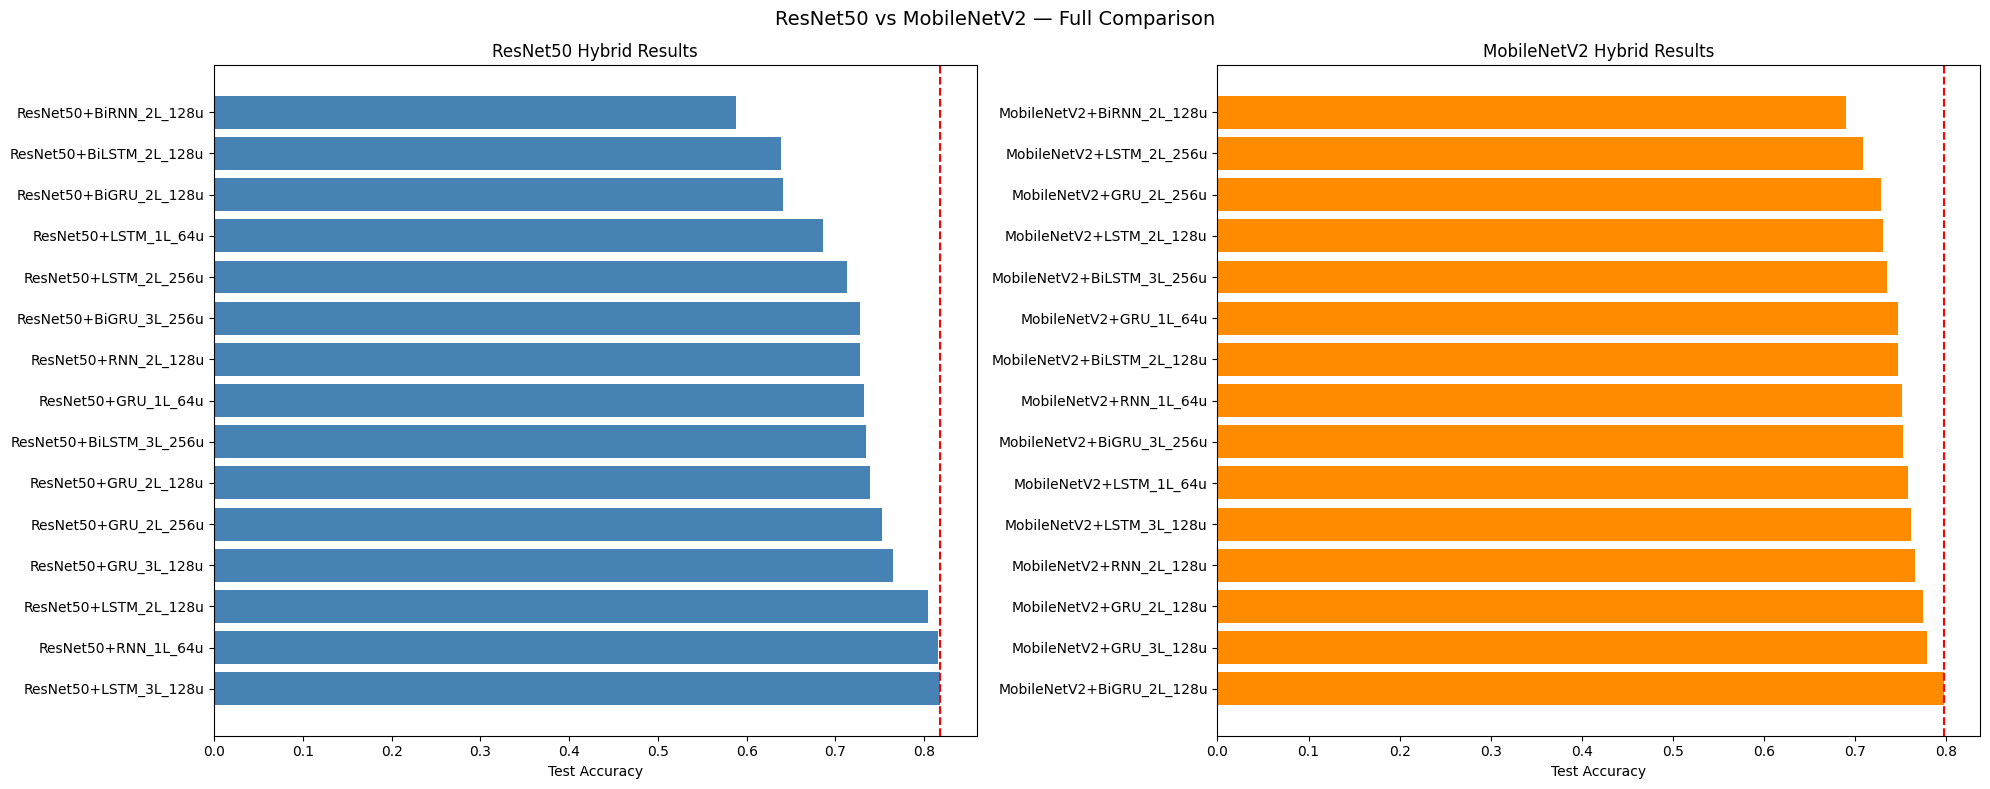

In [8]:
df_resnet = pd.read_csv('/kaggle/input/datasets/annn51/mobilenetv2-datasets/models/resnet50_results.csv',index_col=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].barh(df_resnet.index,    df_resnet['test_acc'],    color='steelblue')
axes[0].axvline(df_resnet['test_acc'].max(), color='red', linestyle='--')
axes[0].set_title('ResNet50 Hybrid Results')
axes[0].set_xlabel('Test Accuracy')

axes[1].barh(df_mobilenet.index, df_mobilenet['test_acc'], color='darkorange')
axes[1].axvline(df_mobilenet['test_acc'].max(), color='red', linestyle='--')
axes[1].set_title('MobileNetV2 Hybrid Results')
axes[1].set_xlabel('Test Accuracy')

plt.suptitle('ResNet50 vs MobileNetV2 — Full Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'final_comparison.png'))
plt.show()


# Overall best

In [9]:
all_results = pd.concat([df_resnet, df_mobilenet])
best        = all_results.sort_values('test_acc', ascending=False).iloc[0]
print(f"\n{'='*55}")
print(f"OVERALL BEST MODEL: {best.name}")
print(f"Test Accuracy:      {best['test_acc']:.4f}")
print(f"Val Accuracy:       {best['val_acc']:.4f}")


OVERALL BEST MODEL: ResNet50+LSTM_3L_128u
Test Accuracy:      0.8182
Val Accuracy:       0.8313
